:::{admonition} Download
:class: important

Download this notebook: **{nb-download}`variable_selection_group_lasso.ipynb`**!

:::


(variable_selection_group_lasso)=
# Selecting Covariates via Group Lasso

## Overview

Fitting an encoding model—such as a Generalized Linear Model (GLM)—with multiple predictors is common practice in neuroscience (e.g., speed and position, head direction and theta phase, multiple stimulus features). When working with many potential covariates, a key question arises: **which predictors actually contribute to neural activity?**

The [GroupLasso](nemos.regularizer.GroupLasso) regularizer addresses this by performing **structured variable selection**: it can shrink entire groups of related coefficients to exactly zero, effectively removing uninformative predictors from the model. This is particularly useful when:

- Working with basis expansions (e.g., splines, raised cosines) where each covariate is represented by multiple coefficients
- Testing multiple competing hypotheses about neural coding
- Building interpretable models by identifying the minimal set of informative features

In this guide, we demonstrate how to use Group Lasso to identify the most informative covariates from a set of candidates.

## Generating Example Data

We begin by generating artificial data consisting of an animal's position on a linear maze, its speed, and simultaneously recorded spike counts. The true model only depends on position.

In [1]:
import nemos as nmo
import numpy as np
np.random.seed(123)

n_samples = 100

# Dummy behavioral data
position = np.random.randn(n_samples)
speed = np.random.randn(n_samples)

# Nonlinear response to position
n_basis = 5
bas = nmo.basis.BSplineEval(n_basis)
coef = np.random.randn(n_basis)
X = bas.compute_features(position)

# Simulated response
firing = np.exp(np.dot(X, coef))
counts = np.random.poisson(firing)

## Fitting a Group Lasso GLM

Next, we model the neuronal response using both position and speed as candidate predictors. We represent each covariate with a [basis expansion](table-basis), creating multiple coefficients per covariate. Since NeMoS GLM supports any JAX PyTrees input type, we can organize these features into a Python `dict`, which allows Group Lasso to treat each covariate's coefficients as a separate group.

:::{admonition} JAX PyTrees
:class: note

Features can be organized in any [JAX PyTree](https://docs.jax.dev/en/latest/pytrees.html), of which `dict` is just a possible example. See our [background note](pytrees_background) on PyTrees to learn more about the topic.
:::

**Key insight**: When using `dict` or any other PyTree with Group Lasso (without specifying a custom mask), each feature in the PyTree is automatically treated as a separate group. This means the model can shrink all coefficients for a particular covariate (e.g., "speed") to zero together, effectively performing variable selection.

(100, 12)
Dictionary of predictors with keys: dict_keys(['position', 'speed'])


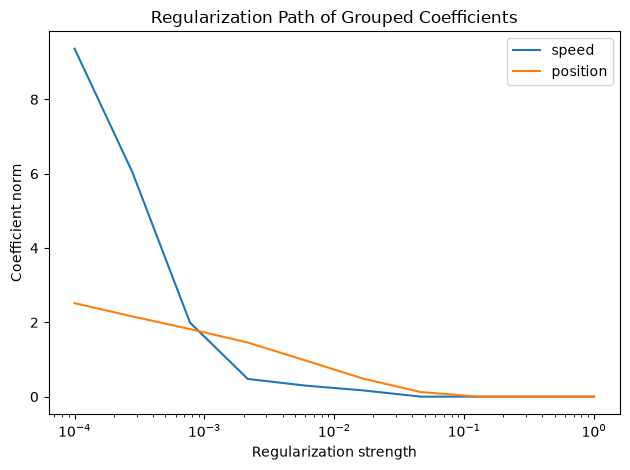

In [2]:
import matplotlib.pyplot as plt

bas = (
    nmo.basis.RaisedCosineLinearEval(6, label="position") +
    nmo.basis.RaisedCosineLinearEval(6, label="speed")
)
predictors = bas.compute_features(position, speed)
print(predictors.shape)

predictors = bas.split_by_feature(predictors)
print(f"Dictionary of predictors with keys: {predictors.keys()}")

# Define a GroupLasso GLM
# Each leaf of the pytree is treated as a group and shrunk jointly
model = nmo.glm.GLM(regularizer="GroupLasso", solver_kwargs={"maxiter": 5000})

# Range of regularization strengths
reg_strengths = np.geomspace(1e-4, 1, 10)

# Containers for coefficient norms
speed_coef_norm = np.zeros(len(reg_strengths))
position_coef_norm = np.zeros(len(reg_strengths))

# Fit model for each regularization strength
for i, reg in enumerate(reg_strengths):
    model.regularizer_strength = reg
    model.fit(predictors, counts)
    speed_coef_norm[i] = np.linalg.norm(model.coef_["speed"])
    position_coef_norm[i] = np.linalg.norm(model.coef_["position"])

# Plot results
fig = plt.figure()
plt.title("Regularization Path of Grouped Coefficients")
plt.xscale("log")
plt.plot(reg_strengths, speed_coef_norm, label="speed")
plt.plot(reg_strengths, position_coef_norm, label="position")
plt.xlabel("Regularization strength")
plt.ylabel("Coefficient norm")
plt.legend()
plt.tight_layout()

In [3]:
# save image for thumbnail
from pathlib import Path
import os

root = os.environ.get("READTHEDOCS_OUTPUT")
if root:
   path = Path(root) / "html/_static/thumbnails/how_to_guide"
# if local store in ../_build/html/...
else:
   path = Path("../_build/html/_static/thumbnails/how_to_guide")

# make sure the folder exists if run from build
if root or Path("../assets/stylesheets").exists():
   path.mkdir(parents=True, exist_ok=True)

if path.exists():
  fig.savefig(path / "variable_selection_group_lasso.svg")

## Interpreting the Results

As the regularization strength increases, the Group Lasso progressively shrinks entire groups of coefficients toward zero. In this example:

1. **At low regularization** (left side): Both position and speed coefficients have non-zero values
2. **At intermediate regularization**: The speed coefficients (the uninformative predictor) are shrunk to zero first
3. **At high regularization** (right side): Both groups are heavily regularized, but position coefficients persist longer

The Group Lasso correctly identifies `position` as the most informative covariate by eliminating the `speed` group first. This demonstrates the method's ability to perform automatic variable selection based on predictive relevance.

## Advanced: Custom Grouping Structures

While the automatic grouping (one group per leaf feature) is convenient for covariate selection, Group Lasso also supports custom grouping structures via explicit masks. This is useful when:

- You want to group coefficients within a single covariate (e.g., grouping spline coefficients by spatial regions)
- Working with multi-neuron recordings where you want to enforce joint sparsity across neurons
- Defining hierarchical or overlapping group structures

For details on specifying custom masks, see the [GroupLasso API documentation](nemos.regularizer.GroupLasso) and the [Group Lasso regularizer tutorial](k-fold-selection).

## Summary

Group Lasso provides a principled approach to covariate selection in neural encoding models:

- **Structured sparsity**: Removes entire groups of coefficients together
- **Automatic grouping**: Works seamlessly with PyTrees for covariate-level selection
- **Flexible**: Supports custom masks for advanced grouping structures
- **Interpretable**: Produces models with fewer, more interpretable predictors

By fitting models across a range of regularization strengths, you can explore which covariates contribute most to neural activity and build more parsimonious encoding models.